This notebook analyzes the spectrum from the results of the Super-Resolution simulation `256_set3_b`. It compares the images from the AI model and a simple bicubic interpolation.

Details of the simulation (and dataset) parameters are stored in `\param_simualtions\256_set3_b`


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.image import imread
from PIL import Image

import pixell
from pixell import enmap
from pixell import curvedsky

In [2]:
def get_cl_from_pixell_map(imap,lmax):
    #remove mean from map before apodize
    imap = imap - np.mean(imap)
    
    # get an apodized mask, multiply the map before doing map2alm
    #we smooth (apodize) the boundaries which we define as a 10% of the pixels
    boundary=int(0.1*imap.shape[0])
    taper_mask = enmap.apod(pixell.enmap.ones(imap.shape, imap.wcs), width=boundary)
    alm_taper = curvedsky.map2alm(taper_mask * imap, lmax=lmax)

    # get the correction factor that accounts for the power lost due to only observing a
    # fraction of the sky
    # enmap.pixsizemap is a map of all the physical pixel areas in steradians
    w2 = np.sum(taper_mask.pixsizemap() * taper_mask**2) / (4*np.pi)

    #alm = pixell.curvedsky.map2alm(imap,lmax=lmax)
    # squaring and averaging over m is done by the alm2cl function
    cl=curvedsky.alm2cl(alm_taper)/w2
    return cl

### Read the images from the simulation (and dataset)

In [3]:
nside = 256 #that's what was used on the data generation (it was the same as the image size)
nside_small = 64 #that's the size of the low-res images

In [4]:
root_folder='results_256_set3_b/'
file_map=root_folder+'256_set3_map.h5'
file_img_hr=root_folder+'88000_3_1_hr.png'
file_img_sr=root_folder+'88000_3_1_sr.png'
file_img_lr=root_folder+'88000_3_1_inf.png' #this is the bicubic upsampled image
file_img_lr_small=root_folder+'88000_3_1_lr.png' #this is the low-res image
#file_img_training=root_folder+'example_image_256_set3_training_set.png' #a random training image (256x256 set3)

In [5]:
lmax=3*nside-1
lmax_small=3*nside_small-1
print('lmax is:',lmax)
print('nside is:',nside)

lmax is: 767
nside is: 256


In [6]:
#read the reference map (contains the wcs) that was used when the dataset was genarated
ref_map= enmap.read_map(file_map,fmt='hdf')

In [7]:
#open all images
img_hr = Image.open(file_img_hr).convert('L')
img_sr = Image.open(file_img_sr).convert('L')
img_lr = Image.open(file_img_lr).convert('L')
img_lr_small = Image.open(file_img_lr_small).convert('L')
#and convert them to numpy array
img_hr_np=np.asarray(img_hr)
img_sr_np=np.asarray(img_sr)
img_lr_np=np.asarray(img_lr)
img_lr_small_np=np.asarray(img_lr_small)
#img_train_np=np.asarray(img_train)

In [8]:
#Double check the size of the arrays
print(np.shape(img_hr_np))
print(np.shape(img_lr_small_np))

(256, 256)
(64, 64)


In [9]:
#create the pixell map from the arrays plus the wcs from the reference map
hr_map=enmap.ndmap(img_hr_np[:,:],wcs=ref_map.wcs)
sr_map=enmap.ndmap(img_sr_np[:,:],wcs=ref_map.wcs)
lr_map=enmap.ndmap(img_lr_np[:,:],wcs=ref_map.wcs)
#but the wcs for the small map should be different (going from 256 to 64 pixels)
#we need to get the new wcs by downgrading the original wcs
wcs_small=enmap.downgrade(hr_map,4).wcs
lr_small_map_down=enmap.ndmap(img_lr_small_np[:,:],wcs=wcs_small)

### Comparison between SR(AI,Bicubic) and HR image

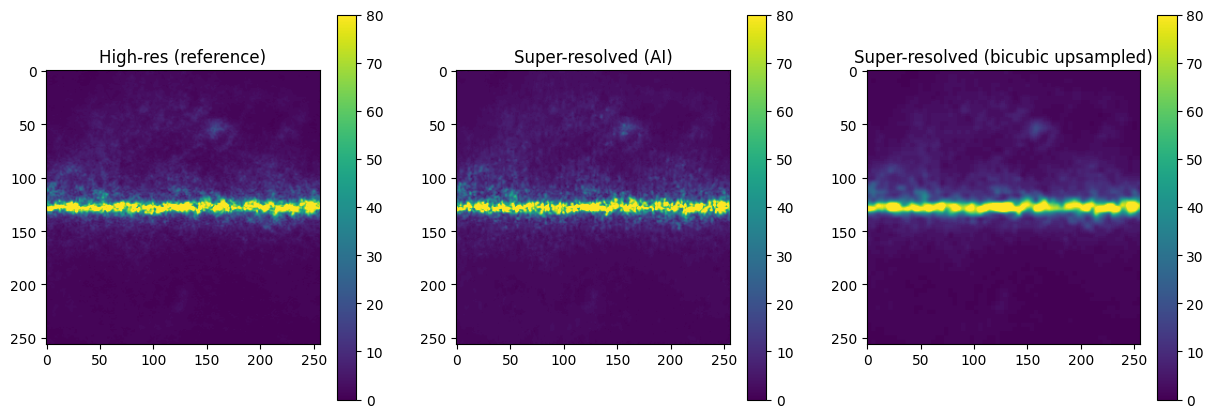

In [10]:
max_scale=80
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title('High-res (reference)')
plt.imshow(hr_map,vmin=0,vmax=max_scale)
plt.colorbar()
plt.subplot(1,3,2)
plt.title('Super-resolved (AI)')
plt.imshow(sr_map,vmin=0,vmax=max_scale)
plt.colorbar()
plt.subplot(1,3,3)
plt.title('Super-resolved (bicubic upsampled)')
plt.imshow(lr_map,vmin=0,vmax=max_scale)
plt.colorbar()

### Calculate the spectrum from the pixell maps

In [11]:
cl_hr=get_cl_from_pixell_map(hr_map[:,:],lmax)
cl_sr=get_cl_from_pixell_map(sr_map[:,:],lmax)
cl_lr=get_cl_from_pixell_map(lr_map[:,:],lmax)
#cl_lr_small=get_cl_from_pixell_map(lr_small_map[:,:],lmax)
cl_lr_small_down=get_cl_from_pixell_map(lr_small_map_down[:,:],lmax_small)

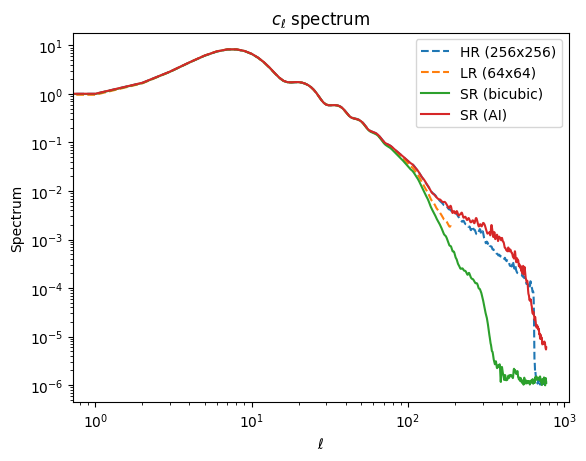

In [12]:
#plt.plot(cl_train,label='Random Training image (256x256)')
plt.plot(cl_hr,linestyle='--',label='HR (256x256)')
#plt.plot(cl_lr_small,label='LR (64x64) ') #was the using the wrong wcs
plt.plot(cl_lr_small_down,linestyle='--',label='LR (64x64)') #using the downgraded wcs
plt.plot(cl_lr,label='SR (bicubic)')
plt.plot(cl_sr,label='SR (AI)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel('Spectrum')
plt.title(r'$c_\ell$ spectrum')
plt.legend()

In the above plot:
- HR: high resolution image, calculated directly from the pysm genereated images
- LR: low resolution 64x6. It was downscaled by Pytorch (from the flat 256x256 HR image) bu we used the reduced wcs to calculate the spectrum
- SR (bicubic): Pytorch upscale of the LR
- SR(AI): The results from using the SR model (note it was using the LR for training)

The plot shows that SR using bicubic method is not good (as expected). On the other hand, AI results are relatively good, spectrum at high *ell* is still high although the slope is not the same. Notice that the LR(64x64) at high **ell** doesn't follow exactly the same slope as the HR. That is due the fact that LR was generated from HR using Pillow (as it was a simple **flat** image). This issue is analyzed in next section.

### Downgrading image with pixell
We want to check if downgrading the image from Pytorch (pillow behind the scenes) has any impact.
Here we will downgrade the HR image using pixell and compare it with the other results

In [13]:
#smooth_map=enmap.smooth_gauss(hr_map,sigma=0.005)
factor =4 #from 256 to 64
smooth_map=enmap.downgrade_fft(hr_map,factor)

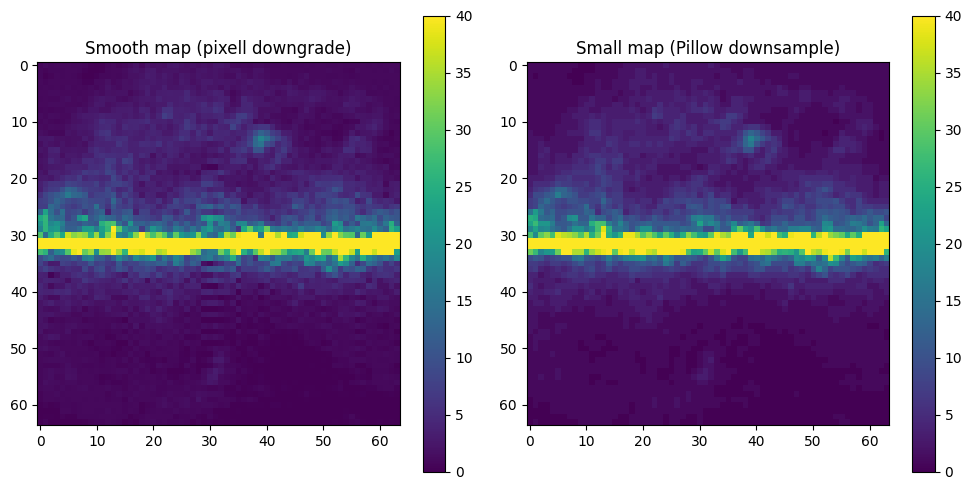

In [ ]:
# Plot smooth map (pixell) and small map (pillow) side by side
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Smooth map (pixell downgrade)')
plt.imshow(smooth_map, vmin=0, vmax=40)
plt.colorbar()
plt.subplot(1,2,2)
plt.title('Small map (Pillow downsample)')
plt.imshow(lr_small_map_down, vmin=0, vmax=40)
plt.colorbar()
plt.tight_layout()

In [15]:
cl_smooth=get_cl_from_pixell_map(smooth_map[:,:],lmax_small)

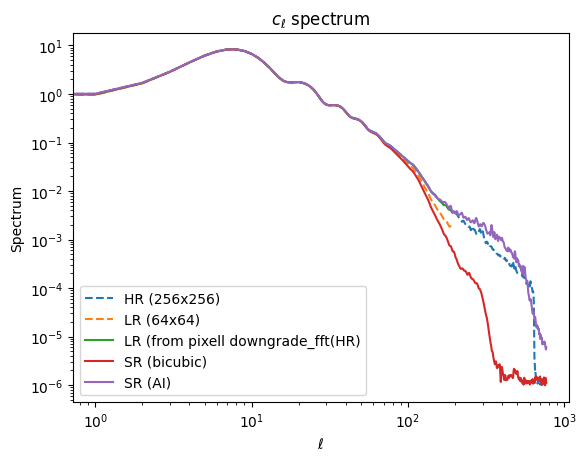

In [19]:
plt.plot(cl_hr,linestyle='--',label='HR (256x256)')
plt.plot(cl_lr_small_down,linestyle='--',label='LR (64x64)') #using the downgraded wcs
plt.plot(cl_smooth,label='LR (from pixell downgrade_fft(HR)')
plt.plot(cl_lr,label='SR (bicubic)')
plt.plot(cl_sr,label='SR (AI)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel('Spectrum')
plt.title(r'$c_\ell$ spectrum')
#plt.ylim(1e-3,1e6)
plt.legend()

It seems like there is no big difference between the two LR except for higher *ell*. Although The LR from pixell does follow the same curve as the original HR (note it is on top of it)